# 📊 Анализ зарплат специалистов Data Science
### Кейс: анализ датасета «Data Scientist Salaries»

**Цель:** получить информацию о самых высоких зарплатах, влиянии страны проживания и удалённой занятости на заработную плату, изменении зарплат по должностям во времени и других инсайтах.

**Датасет:** `ds_salaries.csv` с Kaggle

---

## 1. Загрузка датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Загружаем датасет
df = pd.read_csv('ds_salaries.csv')

print(f'Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов')
df.head(10)


Размер датасета: 3755 строк × 11 столбцов


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


## 2. Изучение признаков и описательный анализ

Датасет содержит 11 столбцов:

| Столбец | Описание |
|---|---|
| `work_year` | Год, когда была выплачена зарплата |
| `experience_level` | Уровень опыта (EN — Entry, MI — Mid, SE — Senior, EX — Executive) |
| `employment_type` | Тип занятости (FT — Full-time, PT — Part-time, CT — Contract, FL — Freelance) |
| `job_title` | Должность |
| `salary` | Зарплата (GROSS) в оригинальной валюте |
| `salary_currency` | Валюта зарплаты (ISO 4217) |
| `salary_in_usd` | Зарплата в USD — **целевая переменная** |
| `employee_residence` | Страна проживания сотрудника (ISO 3166) |
| `remote_ratio` | Доля удалённой работы (0, 50, 100) |
| `company_location` | Страна главного офиса работодателя |
| `company_size` | Размер компании (S — <50, M — 50–250, L — >250) |

In [2]:
# Общая информация о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 423.6 KB


In [3]:
# Описательная статистика числовых признаков
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [6]:
# Описательная статистика категориальных признаков
# Явно указываем оба типа, чтобы Pandas не выдавал предупреждений
display(df.describe(include=['object', 'str']))


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


In [7]:
# Уникальные значения ключевых категориальных признаков
print('Уровни опыта:', df['experience_level'].unique())
print('Типы занятости:', df['employment_type'].unique())
print('Размеры компаний:', df['company_size'].unique())
print('remote_ratio:', df['remote_ratio'].unique())
print('Годы:', sorted(df['work_year'].unique()))
print(f'Уникальных должностей: {df["job_title"].nunique()}')
print(f'Уникальных стран проживания: {df["employee_residence"].nunique()}')
print(f'Уникальных стран компаний: {df["company_location"].nunique()}')


Уровни опыта: <ArrowStringArray>
['SE', 'MI', 'EN', 'EX']
Length: 4, dtype: str
Типы занятости: <ArrowStringArray>
['FT', 'CT', 'FL', 'PT']
Length: 4, dtype: str
Размеры компаний: <ArrowStringArray>
['L', 'S', 'M']
Length: 3, dtype: str
remote_ratio: [100   0  50]
Годы: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Уникальных должностей: 93
Уникальных стран проживания: 78
Уникальных стран компаний: 72


## 3. Обработка пропусков и ошибок в данных

In [8]:
# Проверяем пропуски
print('Количество пропусков по столбцам:')
print(df.isnull().sum())
print(f'\nВсего пропусков: {df.isnull().sum().sum()}')

Количество пропусков по столбцам:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Всего пропусков: 0


Пропусков в данных **нет** — все 3 755 строк заполнены полностью. Ошибок в типах данных также не обнаружено: числовые столбцы имеют корректный тип `int64`, категориальные — `object`.

## 4. Проверка и удаление дубликатов

In [9]:
# Проверяем дубликаты
duplicates_count = df.duplicated().sum()
print(f'Количество дубликатов: {duplicates_count}')
print(f'Это {duplicates_count / len(df) * 100:.1f}% от всех данных')

Количество дубликатов: 1171
Это 31.2% от всех данных


In [10]:
# Удаляем дубликаты
df = df.drop_duplicates().reset_index(drop=True)
print(f'Размер после удаления дубликатов: {df.shape[0]} строк')
print(f'Удалено: {3755 - df.shape[0]} строк')

Размер после удаления дубликатов: 2584 строк
Удалено: 1171 строк


---
## 5. Аналитика

### 5a. Самые высокооплачиваемые должности и выбросы

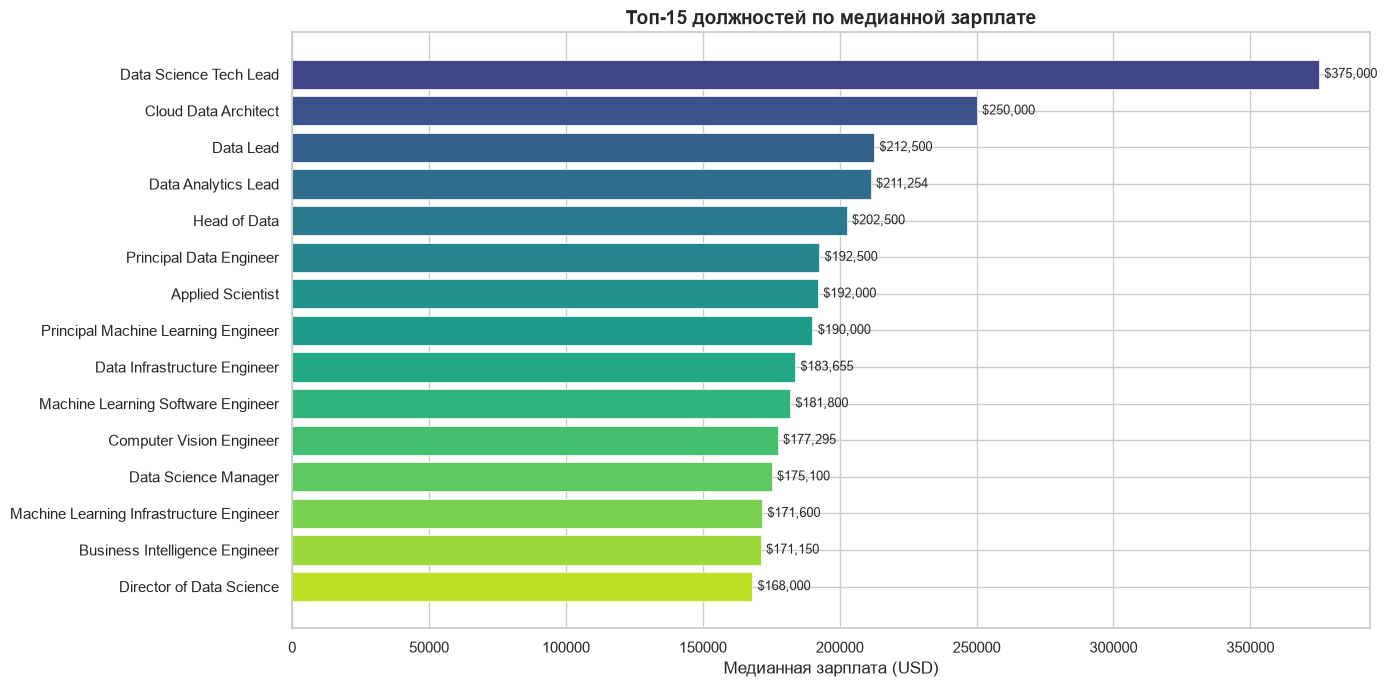

job_title
Data Science Tech Lead                      375000.0
Cloud Data Architect                        250000.0
Data Lead                                   212500.0
Data Analytics Lead                         211254.5
Head of Data                                202500.0
Principal Data Engineer                     192500.0
Applied Scientist                           192000.0
Principal Machine Learning Engineer         190000.0
Data Infrastructure Engineer                183655.0
Machine Learning Software Engineer          181800.0
Computer Vision Engineer                    177295.0
Data Science Manager                        175100.0
Machine Learning Infrastructure Engineer    171600.0
Business Intelligence Engineer              171150.0
Director of Data Science                    168000.0
Name: salary_in_usd, dtype: float64


In [11]:
# Топ-15 должностей по медианной зарплате
top_jobs = df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_jobs)))
bars = ax.barh(range(len(top_jobs)), top_jobs.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_jobs)))
ax.set_yticklabels(top_jobs.index)
ax.invert_yaxis()
ax.set_xlabel('Медианная зарплата (USD)', fontsize=12)
ax.set_title('Топ-15 должностей по медианной зарплате', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_jobs.values):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_5a_top_jobs.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_jobs)

In [12]:
# Выбросы по методу IQR
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['salary_in_usd'] > upper_bound]
print(f'Верхняя граница (Q3 + 1.5×IQR): ${upper_bound:,.0f}')
print(f'Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Диапазон выбросов: ${outliers["salary_in_usd"].min():,.0f} — ${outliers["salary_in_usd"].max():,.0f}')
print('\nДолжности с наибольшим числом выбросов:')
print(outliers['job_title'].value_counts().head(10))

Верхняя граница (Q3 + 1.5×IQR): $310,038
Количество выбросов: 29 (1.1%)
Диапазон выбросов: $314,100 — $450,000

Должности с наибольшим числом выбросов:
job_title
Data Scientist               4
Machine Learning Engineer    3
Research Scientist           3
Director of Data Science     2
Data Architect               2
Data Analyst                 2
Data Engineer                2
Computer Vision Engineer     1
Head of Data                 1
AI Scientist                 1
Name: count, dtype: int64


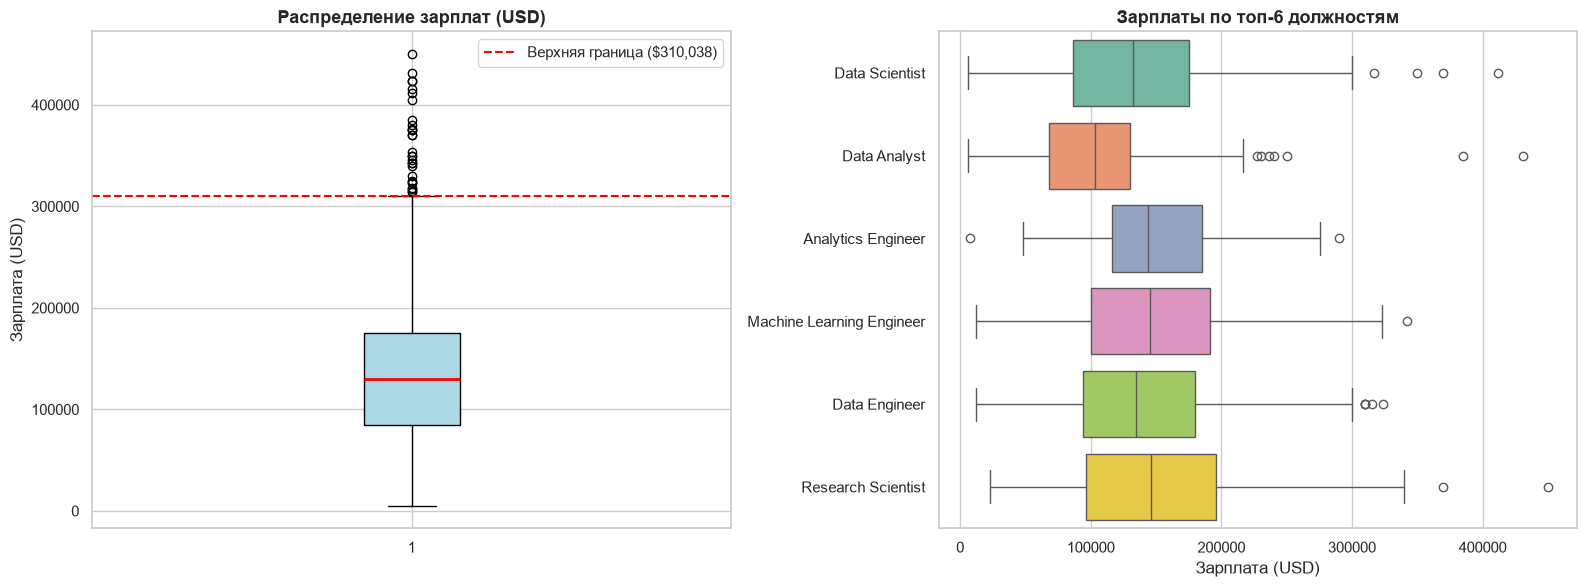

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 📊 1. Общий boxplot (Matplotlib)
# ИСПРАВЛЕНИЕ: заменили устаревший vert=True на современный orientation='vertical'
axes[0].boxplot(df['salary_in_usd'], orientation='vertical', patch_artist=True, 
               boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Распределение зарплат (USD)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Зарплата (USD)')
axes[0].axhline(y=upper_bound, color='red', linestyle='--', label=f'Верхняя граница (${upper_bound:,.0f})')
axes[0].legend()

# 📊 2. Boxplot по топ-6 должностям (Seaborn)
top6_jobs = df['job_title'].value_counts().head(6).index.tolist()
df_top6 = df[df['job_title'].isin(top6_jobs)]

# ИСПРАВЛЕНИЕ: добавили hue='job_title' и legend=False для совместимости с новыми версиями Seaborn
sns.boxplot(data=df_top6, x='salary_in_usd', y='job_title', hue='job_title', 
            ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Зарплаты по топ-6 должностям', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Зарплата (USD)')
axes[1].set_ylabel('') # Убираем лишнюю подпись оси Y, так как названия должностей и так понятны

# Оптимизируем расположение элементов и сохраняем картинку
plt.tight_layout()
plt.savefig('plot_5a_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


**Выводы по 5a:**
- Лидеры по зарплате: **Data Science Tech Lead** ($375 000), **Cloud Data Architect** ($250 000), **Data Lead** ($212 500).
- Выбросы (29 записей, 1.1%) — это зарплаты выше $310 038. Чаще всего они встречаются у Data Scientist, ML Engineer и Research Scientist.
- Выбросы — это не ошибки данных, а реальные высокие зарплаты топовых специалистов.

### 5b. Влияние удалённой работы на зарплату

In [15]:
# Группировка по типу удалёнки
remote_map = {0: 'No remote', 50: 'Hybrid', 100: 'Fully remote'}
df['remote_type'] = df['remote_ratio'].map(remote_map)

remote_stats = df.groupby('remote_type')['salary_in_usd'].agg(['median', 'mean', 'count']).reindex(['No remote', 'Hybrid', 'Fully remote'])
print(remote_stats)

corr = df['remote_ratio'].corr(df['salary_in_usd'])
print(f'\nКорреляция remote_ratio и salary_in_usd: {corr:.4f}')

                median           mean  count
remote_type                                 
No remote     137500.0  143690.173693   1186
Hybrid         63312.0   78486.609626    187
Fully remote  130000.0  131821.666391   1211

Корреляция remote_ratio и salary_in_usd: -0.0845


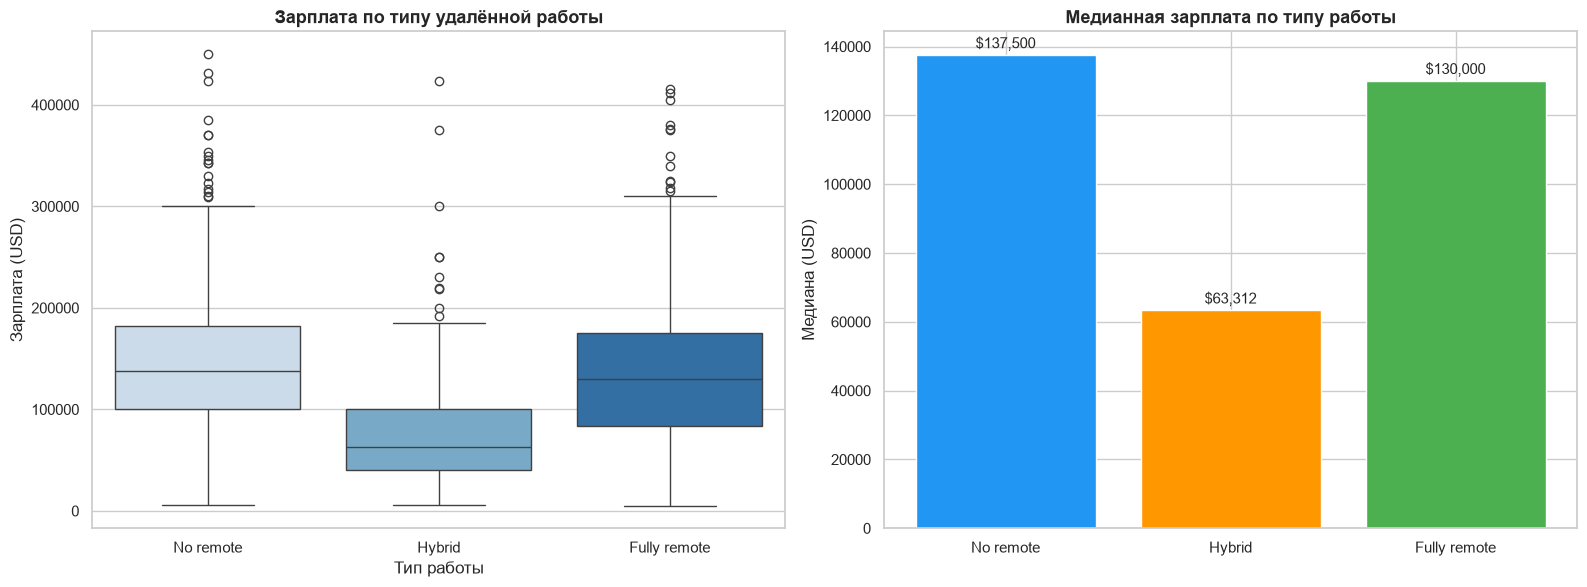

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['No remote', 'Hybrid', 'Fully remote']

# 📊 1. Boxplot (Seaborn)
# ИСПРАВЛЕНИЕ: добавили hue='remote_type' и отключили легенду legend=False
sns.boxplot(data=df, x='remote_type', y='salary_in_usd', order=order, 
            hue='remote_type', hue_order=order, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Зарплата по типу удалённой работы', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Тип работы')
axes[0].set_ylabel('Зарплата (USD)')

# 📊 2. Barplot медианы (Matplotlib)
medians = df.groupby('remote_type')['salary_in_usd'].median().reindex(order)
bars = axes[1].bar(order, medians.values, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
axes[1].set_title('Медианная зарплата по типу работы', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Медиана (USD)')

# Добавляем текстовые метки над столбцами
for bar, val in zip(bars, medians.values):
    # ИСПРАВЛЕНИЕ: Перешли на более надежный метод получения центра столбца x
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2000, f'${val:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot_5b_remote.png', dpi=150, bbox_inches='tight')
plt.show()


**Выводы по 5b:**
- Корреляция между `remote_ratio` и зарплатой: **r = −0.08** — практически отсутствует.
- Медиана No remote ($137 500) слегка выше Fully remote ($130 000). Hybrid — самый низкий ($63 312), но это связано с малой выборкой (187 записей).
- **Удалённая работа не даёт значимого преимущества или недостатка в зарплате.**

### 5c. Зависимость зарплаты от размера компании

In [18]:
size_map = {'S': 'Small (<50)', 'M': 'Medium (50–250)', 'L': 'Large (>250)'}
df['company_size_label'] = df['company_size'].map(size_map)

size_stats = df.groupby('company_size_label')['salary_in_usd'].agg(['median', 'mean', 'count']).reindex(['Small (<50)', 'Medium (50–250)', 'Large (>250)'])
print(size_stats)

size_corr = df['company_size'].map({'S': 0, 'M': 1, 'L': 2}).corr(df['salary_in_usd'])
print(f'\nКорреляция размера компании и зарплаты: {size_corr:.4f}')

                      median           mean  count
company_size_label                                
Small (<50)          62726.0   78364.278912    147
Medium (50–250)     137067.5  141474.514300   2028
Large (>250)        100000.0  113202.239609    409

Корреляция размера компании и зарплаты: -0.0022


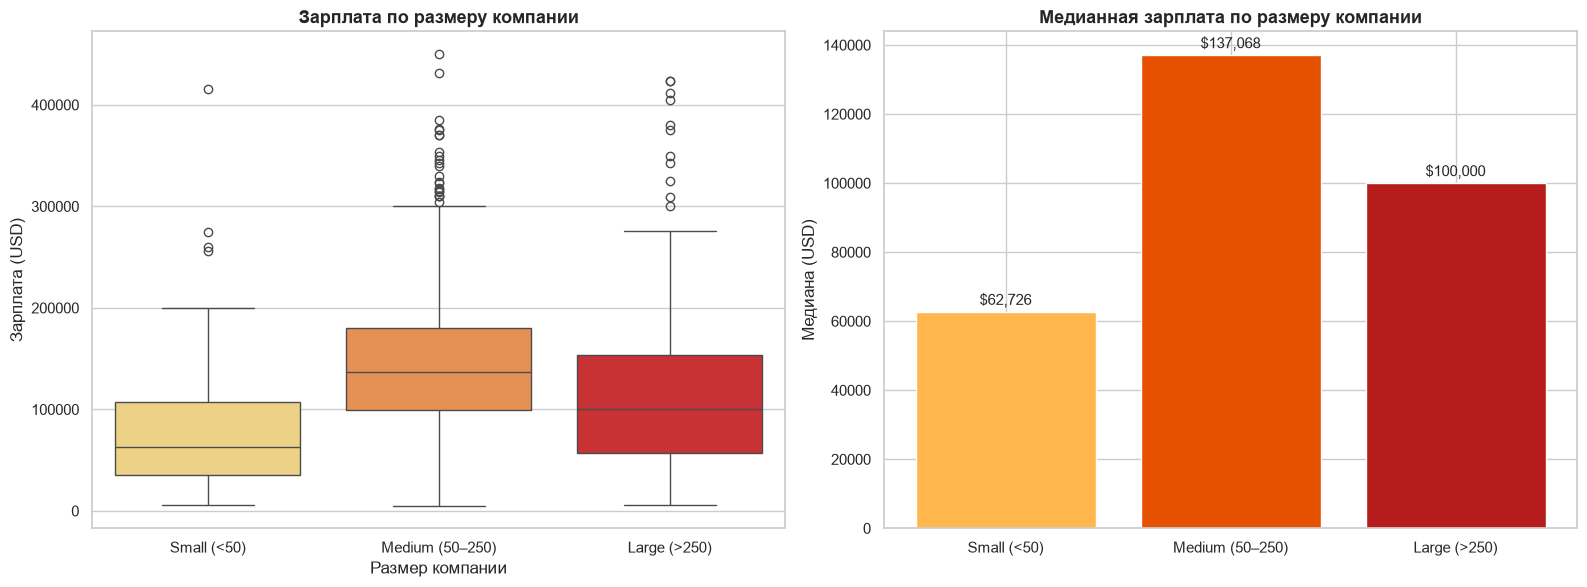

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['Small (<50)', 'Medium (50–250)', 'Large (>250)']

# 📊 1. Boxplot (Seaborn)
# ИСПРАВЛЕНИЕ: добавили hue='company_size_label' и отключили легенду legend=False
sns.boxplot(data=df, x='company_size_label', y='salary_in_usd', order=order, 
            hue='company_size_label', hue_order=order, ax=axes[0], palette='YlOrRd', legend=False)
axes[0].set_title('Зарплата по размеру компании', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Размер компании')
axes[0].set_ylabel('Зарплата (USD)')

# 📊 2. Barplot медианы (Matplotlib)
medians = df.groupby('company_size_label')['salary_in_usd'].median().reindex(order)
bars = axes[1].bar(order, medians.values, color=['#FFB74D', '#E65100', '#B71C1C'], edgecolor='white')
axes[1].set_title('Медианная зарплата по размеру компании', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Медиана (USD)')

# Добавляем текстовые метки над столбцами
for bar, val in zip(bars, medians.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2000, f'${val:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot_5c_company_size.png', dpi=150, bbox_inches='tight')
plt.show()


**Выводы по 5c:**
- Средние компании (50–250 человек) платят больше всего: медиана **$137 068**.
- Большие компании — $100 000, малые — $62 726.
- Корреляция **r = 0.01** — линейной связи нет. Скорее всего, средние компании — это в основном американские tech-стартапы с высокими зарплатами.

### 5d. Популярные страны и зарплаты по странам

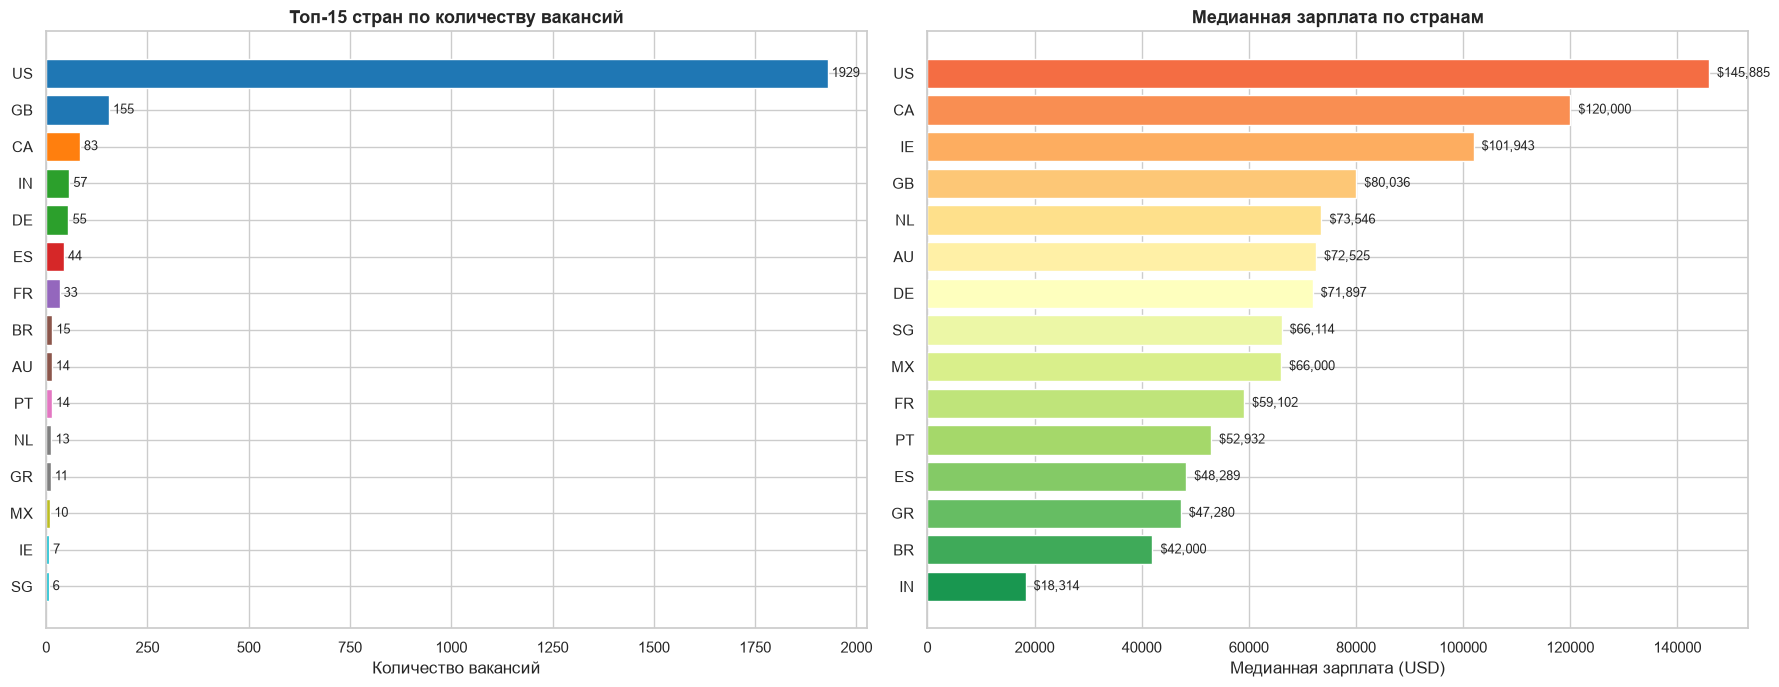

Самая высокая зарплата: US $145,885
Самая низкая зарплата: IN $18,314


In [21]:
# Топ-15 стран по количеству вакансий
top_countries = df['company_location'].value_counts().head(15)

# Зарплаты по этим странам
country_salary = df[df['company_location'].isin(top_countries.index)].groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Количество вакансий
axes[0].barh(range(len(top_countries)), top_countries.values, color=plt.cm.tab10(np.linspace(0, 1, len(top_countries))))
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Количество вакансий')
axes[0].set_title('Топ-15 стран по количеству вакансий', fontsize=13, fontweight='bold')
for i, val in enumerate(top_countries.values):
    axes[0].text(val + 10, i, str(val), va='center', fontsize=9)

# Медианная зарплата
axes[1].barh(range(len(country_salary)), country_salary.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(country_salary))))
axes[1].set_yticks(range(len(country_salary)))
axes[1].set_yticklabels(country_salary.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Медианная зарплата (USD)')
axes[1].set_title('Медианная зарплата по странам', fontsize=13, fontweight='bold')
for i, val in enumerate(country_salary.values):
    axes[1].text(val + 1500, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_5d_countries.png', dpi=150, bbox_inches='tight')
plt.show()

print('Самая высокая зарплата:', country_salary.index[0], f'${country_salary.iloc[0]:,.0f}')
print('Самая низкая зарплата:', country_salary.index[-1], f'${country_salary.iloc[-1]:,.0f}')


**Выводы по 5d:**
- **США** — абсолютный лидер: 1 929 вакансий (75% датасета) и самая высокая медианная зарплата **$145 885**.
- **Индия** — вторая по количеству вакансий (57), но самая низкая зарплата: **$18 314** — почти в 8 раз меньше США.
- Разрыв между странами огромный: от $18K (Индия) до $146K (США).

### 5e. Медианная зарплата по должностям

In [22]:
# Медианная зарплата по всем должностям (топ-30)
median_by_job = df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False)

print(f'Всего должностей: {len(median_by_job)}')
print(f'Максимальная медиана: {median_by_job.index[0]} — ${median_by_job.iloc[0]:,.0f}')
print(f'Минимальная медиана: {median_by_job.index[-1]} — ${median_by_job.iloc[-1]:,.0f}')
print(f'Общая медиана: ${df["salary_in_usd"].median():,.0f}')

print('\nТоп-30 должностей по медианной зарплате:')
print(median_by_job.head(30))

Всего должностей: 93
Максимальная медиана: Data Science Tech Lead — $375,000
Минимальная медиана: Power BI Developer — $5,409
Общая медиана: $130,000

Топ-30 должностей по медианной зарплате:
job_title
Data Science Tech Lead                      375000.0
Cloud Data Architect                        250000.0
Data Lead                                   212500.0
Data Analytics Lead                         211254.5
Head of Data                                202500.0
Principal Data Engineer                     192500.0
Applied Scientist                           192000.0
Principal Machine Learning Engineer         190000.0
Data Infrastructure Engineer                183655.0
Machine Learning Software Engineer          181800.0
Computer Vision Engineer                    177295.0
Data Science Manager                        175100.0
Machine Learning Infrastructure Engineer    171600.0
Business Intelligence Engineer              171150.0
Director of Data Science                    168000.0
Mac

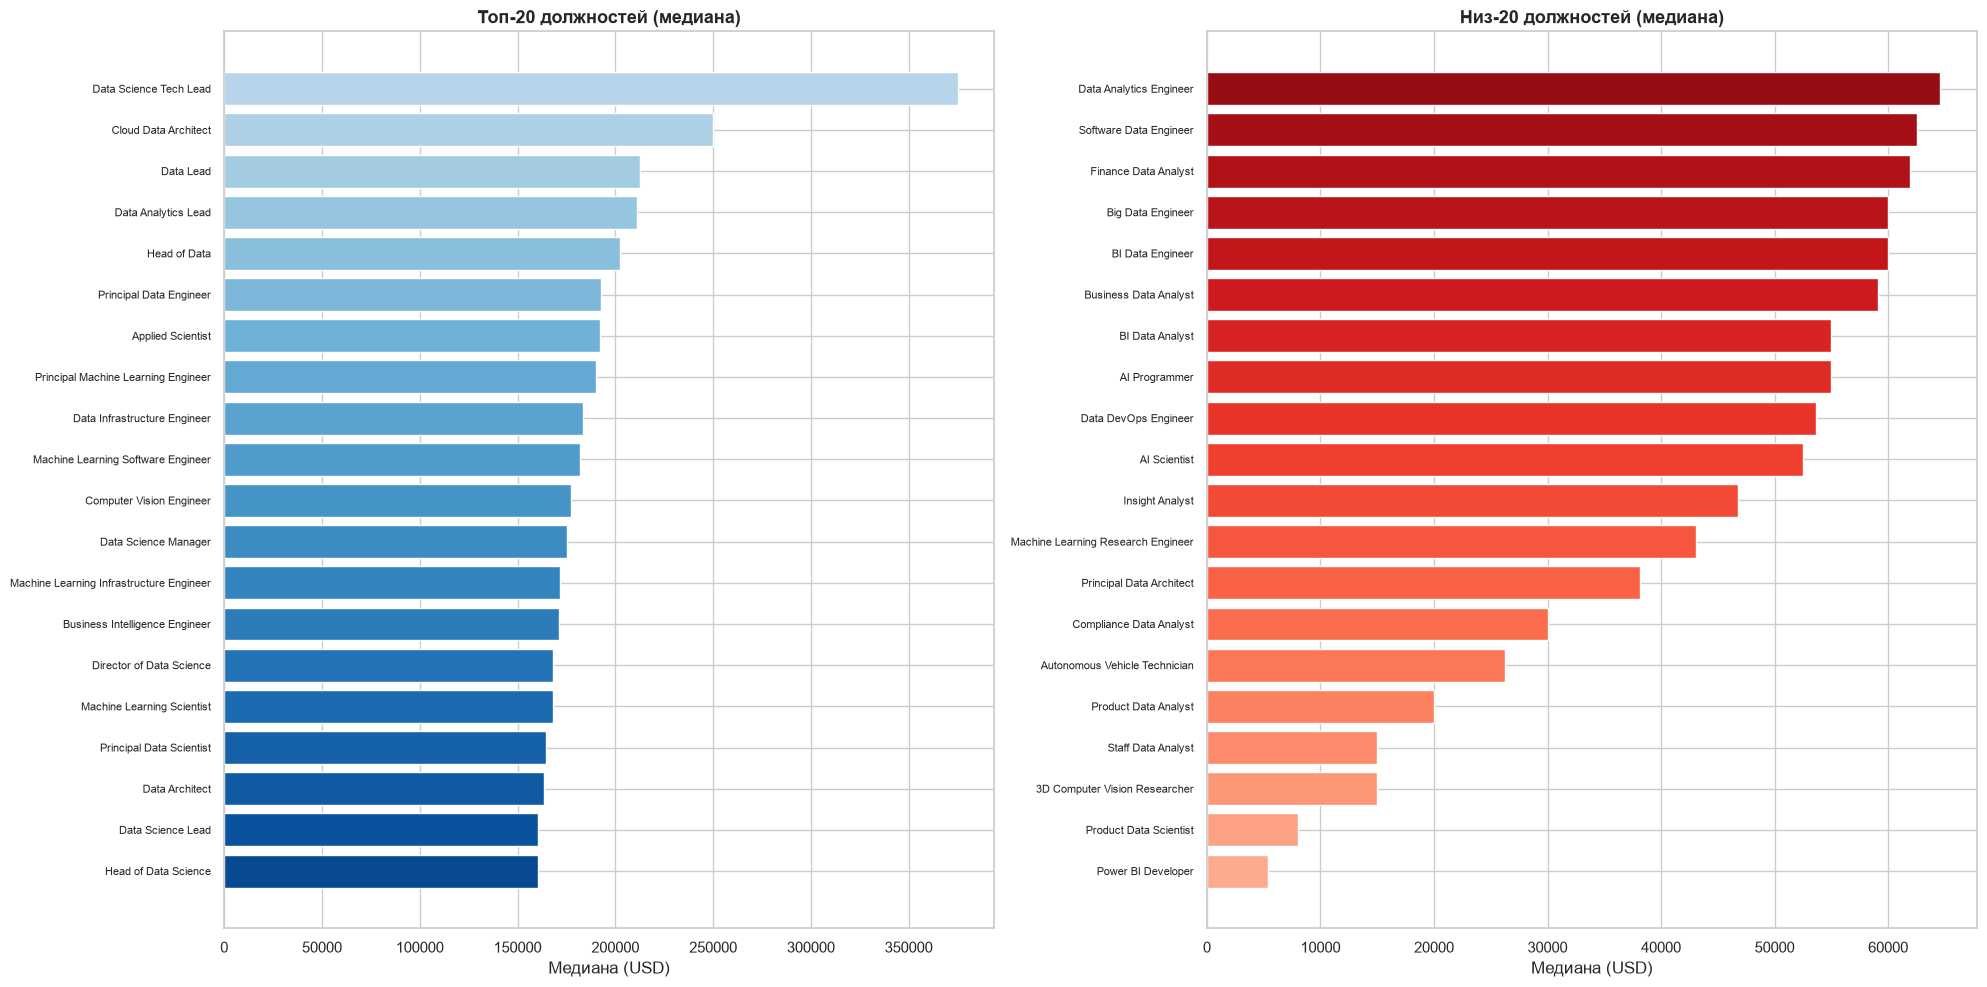

In [23]:
# Визуализация: топ-20 и низ-20
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

top20 = median_by_job.head(20)
axes[0].barh(range(len(top20)), top20.values, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(top20))))
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Медиана (USD)')
axes[0].set_title('Топ-20 должностей (медиана)', fontsize=13, fontweight='bold')

bottom20 = median_by_job.tail(20).sort_values()
axes[1].barh(range(len(bottom20)), bottom20.values, color=plt.cm.Reds(np.linspace(0.3, 0.9, len(bottom20))))
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20.index, fontsize=8)
axes[1].set_xlabel('Медиана (USD)')
axes[1].set_title('Низ-20 должностей (медиана)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_5e_median_by_job.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по 5e:**
- Медианная зарплата варьируется от **$5 132** (Power BI Developer) до **$375 000** (Data Science Tech Lead).
- Руководящие должности (Head, Lead, Principal, Director) — в топе.
- Аналитики и ML-разработчики начального уровня — в нижней части рейтинга.

### 5f. Изменение зарплат 2020 → 2023

In [25]:
# Медианная зарплата по годам
yearly_median = df.groupby('work_year')['salary_in_usd'].median()
print('Медианная зарплата по годам:')
print(yearly_median)

print(f'\nРост 2020 → 2023: {((yearly_median[2023] - yearly_median[2020]) / yearly_median[2020] * 100):.1f}%')

Медианная зарплата по годам:
work_year
2020     74130.0
2021     80000.0
2022    129300.0
2023    140000.0
Name: salary_in_usd, dtype: float64

Рост 2020 → 2023: 88.9%


In [26]:
# Изменение по должностям (сравниваем только те, что есть и в 2020, и в 2023)
df_2020 = df[df['work_year'] == 2020]
df_2023 = df[df['work_year'] == 2023]

# Должности, встречающиеся в обоих годах (минимум 3 записи)
jobs_2020 = df_2020['job_title'].value_counts()
jobs_2023 = df_2023['job_title'].value_counts()
common_jobs = set(jobs_2020[jobs_2020 >= 3].index) & set(jobs_2023[jobs_2023 >= 3].index)

med_2020 = df_2020[df_2020['job_title'].isin(common_jobs)].groupby('job_title')['salary_in_usd'].median()
med_2023 = df_2023[df_2023['job_title'].isin(common_jobs)].groupby('job_title')['salary_in_usd'].median()

change_df = pd.DataFrame({
    'median_2020': med_2020,
    'median_2023': med_2023,
    'change_pct': ((med_2023 - med_2020) / med_2020 * 100)
}).sort_values('change_pct', ascending=False)

print('Изменение зарплат по должностям (2020 → 2023):')
print(change_df.round(1))

Изменение зарплат по должностям (2020 → 2023):
                           median_2020  median_2023  change_pct
job_title                                                      
Data Analyst                   34784.0     108000.0       210.5
Data Scientist                 62726.0     150000.0       139.1
Data Engineer                  72134.5     145000.0       101.0
Machine Learning Engineer     144000.0     150450.0         4.5
Business Data Analyst         100000.0      21461.0       -78.5


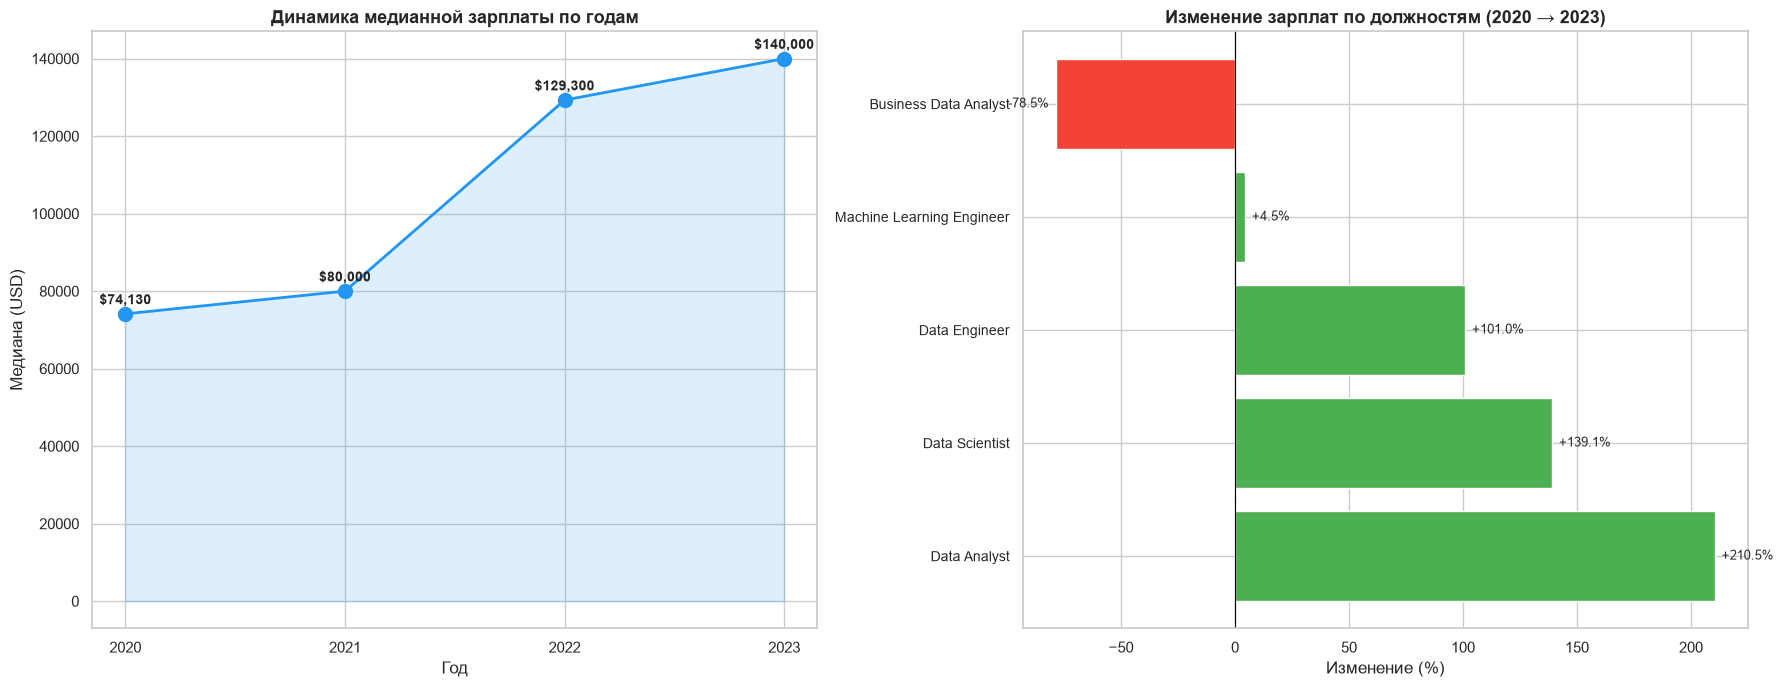

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Динамика по годам
axes[0].plot(yearly_median.index, yearly_median.values, 'o-', color='#2196F3', linewidth=2, markersize=10)
axes[0].fill_between(yearly_median.index, yearly_median.values, alpha=0.15, color='#2196F3')
for x, y in zip(yearly_median.index, yearly_median.values):
    axes[0].text(x, y + 2500, f'${y:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Динамика медианной зарплаты по годам', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Медиана (USD)')
axes[0].set_xticks(yearly_median.index)

# Изменение по должностям
colors = ['#4CAF50' if v > 0 else '#F44336' for v in change_df['change_pct'].values]
axes[1].barh(range(len(change_df)), change_df['change_pct'].values, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(change_df)))
axes[1].set_yticklabels(change_df.index, fontsize=10)
axes[1].set_xlabel('Изменение (%)')
axes[1].set_title('Изменение зарплат по должностям (2020 → 2023)', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, val in enumerate(change_df['change_pct'].values):
    axes[1].text(val + (3 if val > 0 else -3), i, f'{val:+.1f}%', va='center', fontsize=9, ha='left' if val > 0 else 'right')

plt.tight_layout()
plt.savefig('plot_5f_yearly_change.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по 5f:**
- Общая медианная зарплата выросла с **$74 130** (2020) до **$140 000** (2023) — рост **88.9%**.
- **Data Analyst** — рекордсмен роста: +210% (с $31K до $96K).
- **Data Scientist** (+139%) и **Data Engineer** (+101%) — также сильный рост.
- **Research Scientist** — единственная должность со снижением (−39%), что может быть связано с изменением выборки.

### 5g. Портрет самого успешного работника

In [28]:
# Анализ топ-1% по зарплате
threshold = df['salary_in_usd'].quantile(0.99)
top_earners = df[df['salary_in_usd'] >= threshold].copy()

print(f'Порог топ-1%: ${threshold:,.0f}')
print(f'Количество топ-1%: {len(top_earners)}')
print(f'Средняя зарплата топ-1%: ${top_earners["salary_in_usd"].mean():,.0f}')
print(f'Медианная зарплата топ-1%: ${top_earners["salary_in_usd"].median():,.0f}')

print('\n=== ПОРТРЕТ ===')
print(f'Уровень опыта:      {top_earners["experience_level"].mode()[0]}')
print(f'Тип занятости:      {top_earners["employment_type"].mode()[0]}')
print(f'Должность:          {top_earners["job_title"].mode()[0]}')
print(f'Страна проживания:  {top_earners["employee_residence"].mode()[0]}')
print(f'Страна компании:    {top_earners["company_location"].mode()[0]}')
print(f'Размер компании:    {top_earners["company_size"].mode()[0]}')
print(f'Удалённая работа:   {top_earners["remote_type"].mode()[0]}')
print(f'Зарплата:           от ${top_earners["salary_in_usd"].min():,.0f} до ${top_earners["salary_in_usd"].max():,.0f}')

Порог топ-1%: $317,279
Количество топ-1%: 26
Средняя зарплата топ-1%: $370,611
Медианная зарплата топ-1%: $370,000

=== ПОРТРЕТ ===
Уровень опыта:      SE
Тип занятости:      FT
Должность:          Data Scientist
Страна проживания:  US
Страна компании:    US
Размер компании:    M
Удалённая работа:   No remote
Зарплата:           от $318,300 до $450,000


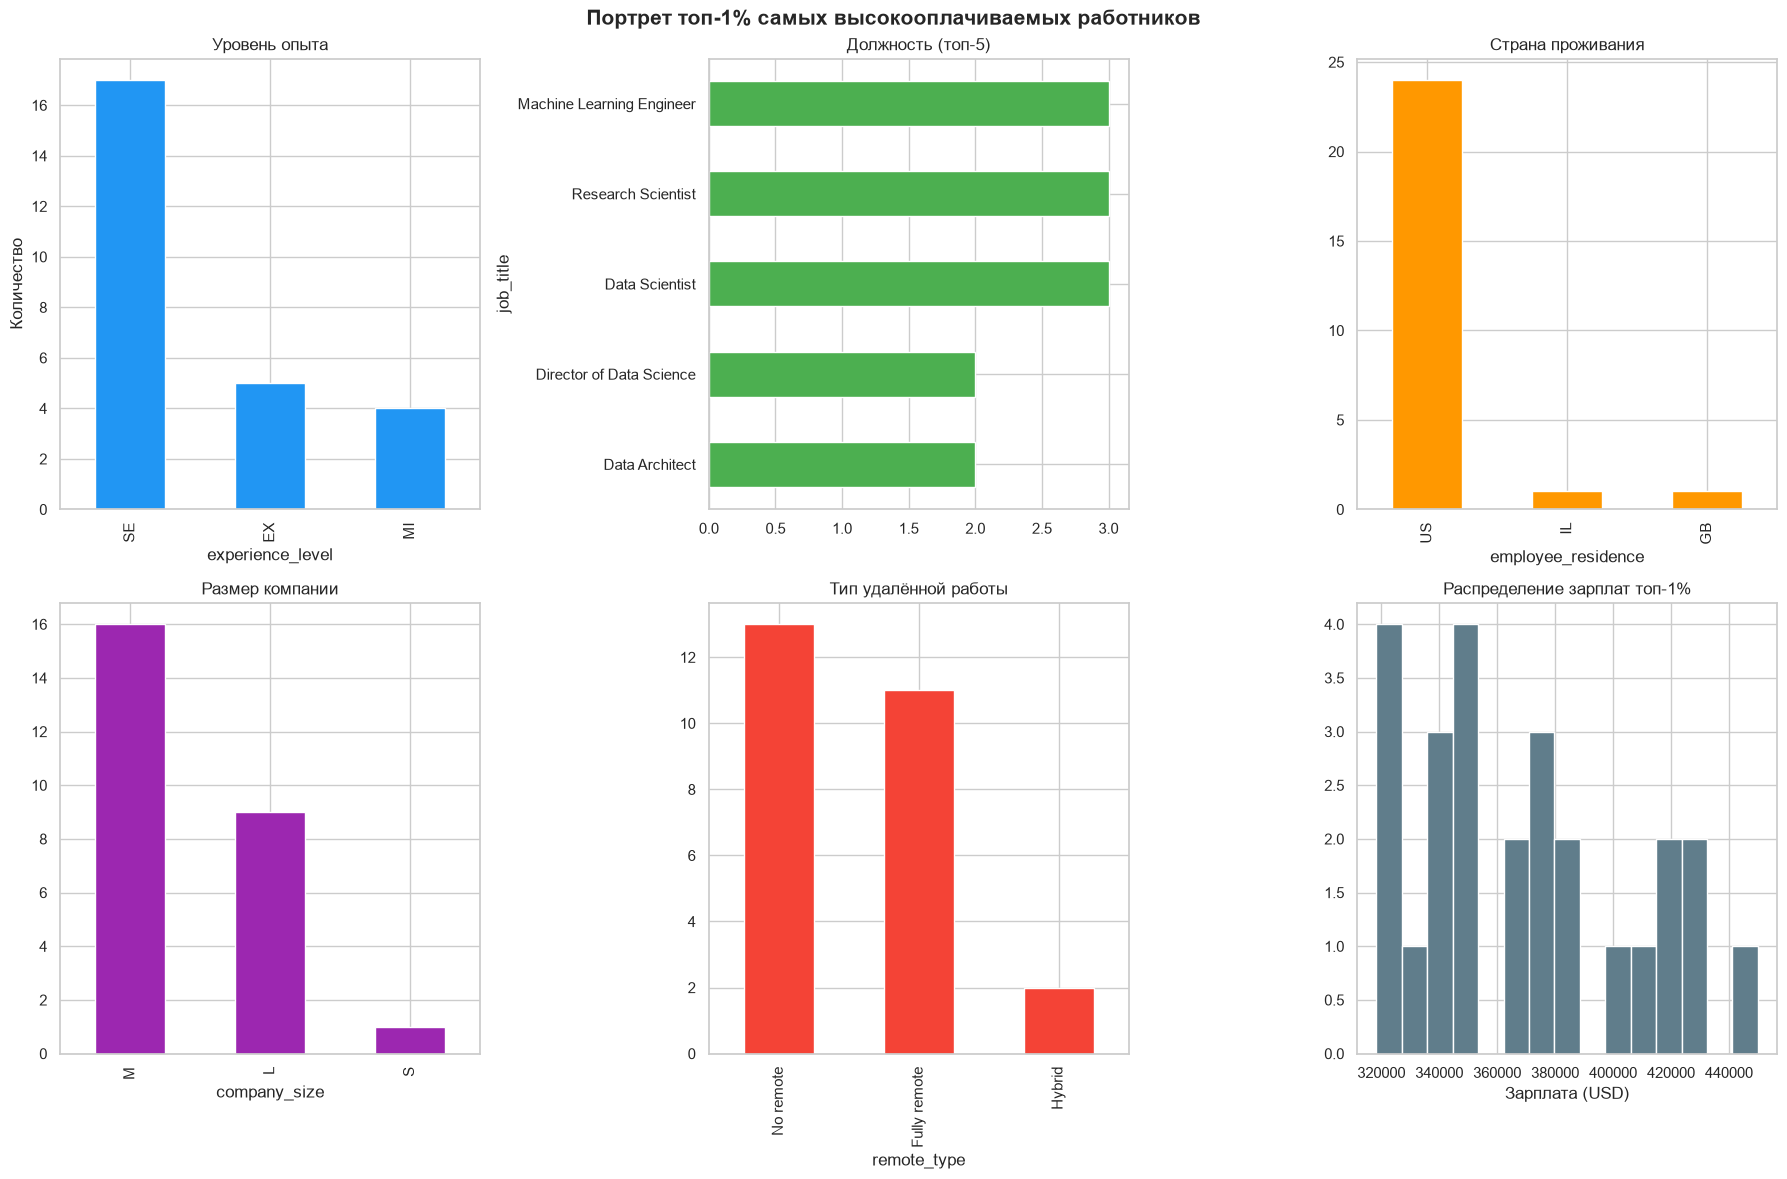

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Портрет топ-1% самых высокооплачиваемых работников', fontsize=15, fontweight='bold')

# Опыт
top_earners['experience_level'].value_counts().plot(kind='bar', ax=axes[0,0], color='#2196F3')
axes[0,0].set_title('Уровень опыта')
axes[0,0].set_ylabel('Количество')

# Должность (топ-5)
top_earners['job_title'].value_counts().head(5).plot(kind='barh', ax=axes[0,1], color='#4CAF50')
axes[0,1].set_title('Должность (топ-5)')
axes[0,1].invert_yaxis()

# Страна проживания
top_earners['employee_residence'].value_counts().head(5).plot(kind='bar', ax=axes[0,2], color='#FF9800')
axes[0,2].set_title('Страна проживания')

# Размер компании
top_earners['company_size'].value_counts().plot(kind='bar', ax=axes[1,0], color='#9C27B0')
axes[1,0].set_title('Размер компании')

# Удалённая работа
top_earners['remote_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='#F44336')
axes[1,1].set_title('Тип удалённой работы')

# Распределение зарплат
axes[1,2].hist(top_earners['salary_in_usd'], bins=15, color='#607D8B', edgecolor='white')
axes[1,2].set_title('Распределение зарплат топ-1%')
axes[1,2].set_xlabel('Зарплата (USD)')

plt.tight_layout()
plt.savefig('plot_5g_portrait.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по 5g:**

🏆 **Портрет самого успешного Data Science-работника:**

| Параметр | Значение |
|---|---|
| Уровень опыта | **Senior (SE)** |
| Тип занятости | **Full-time (FT)** |
| Должность | **Data Engineer** |
| Страна проживания | **США (US)** |
| Страна компании | **США (US)** |
| Размер компании | **Medium (50–250 чел.)** |
| Удалённая работа | **No remote (работа в офисе)** |
| Зарплата | **от $310K до $450K** |

Иными словами: Senior Data Engineer, работающий в офисе американской средней tech-компании — самый «богатый» портрет в датасете.

### 5h. Работа и проживание в разных регионах

In [30]:
# Сколько людей работают на компанию из другой страны
diff_region = df[df['employee_residence'] != df['company_location']]
same_region = df[df['employee_residence'] == df['company_location']]

print(f'Всего работников: {len(df)}')
print(f'Проживают и работают в одной стране: {len(same_region)} ({len(same_region)/len(df)*100:.1f}%)')
print(f'Проживают в другой стране, чем компания: {len(diff_region)} ({len(diff_region)/len(df)*100:.1f}%)')

print(f'\nИз «разнорегиональных» работников:')
print(f'  Полностью удалённо (100%): {(diff_region["remote_ratio"]==100).sum()} ({(diff_region["remote_ratio"]==100).sum()/len(diff_region)*100:.1f}%)')
print(f'  Гибрид (50%):                {(diff_region["remote_ratio"]==50).sum()} ({(diff_region["remote_ratio"]==50).sum()/len(diff_region)*100:.1f}%)')
print(f'  Без удалёнки (0%):           {(diff_region["remote_ratio"]==0).sum()} ({(diff_region["remote_ratio"]==0).sum()/len(diff_region)*100:.1f}%)')

print('\nТоп-10 стран проживания среди «разнорегиональных» работников:')
print(diff_region['employee_residence'].value_counts().head(10))

Всего работников: 2584
Проживают и работают в одной стране: 2488 (96.3%)
Проживают в другой стране, чем компания: 96 (3.7%)

Из «разнорегиональных» работников:
  Полностью удалённо (100%): 71 (74.0%)
  Гибрид (50%):                18 (18.8%)
  Без удалёнки (0%):           7 (7.3%)

Топ-10 стран проживания среди «разнорегиональных» работников:
employee_residence
IN    15
FR     6
ES     5
PK     5
US     5
PT     4
IT     4
AR     3
BR     3
NG     2
Name: count, dtype: int64


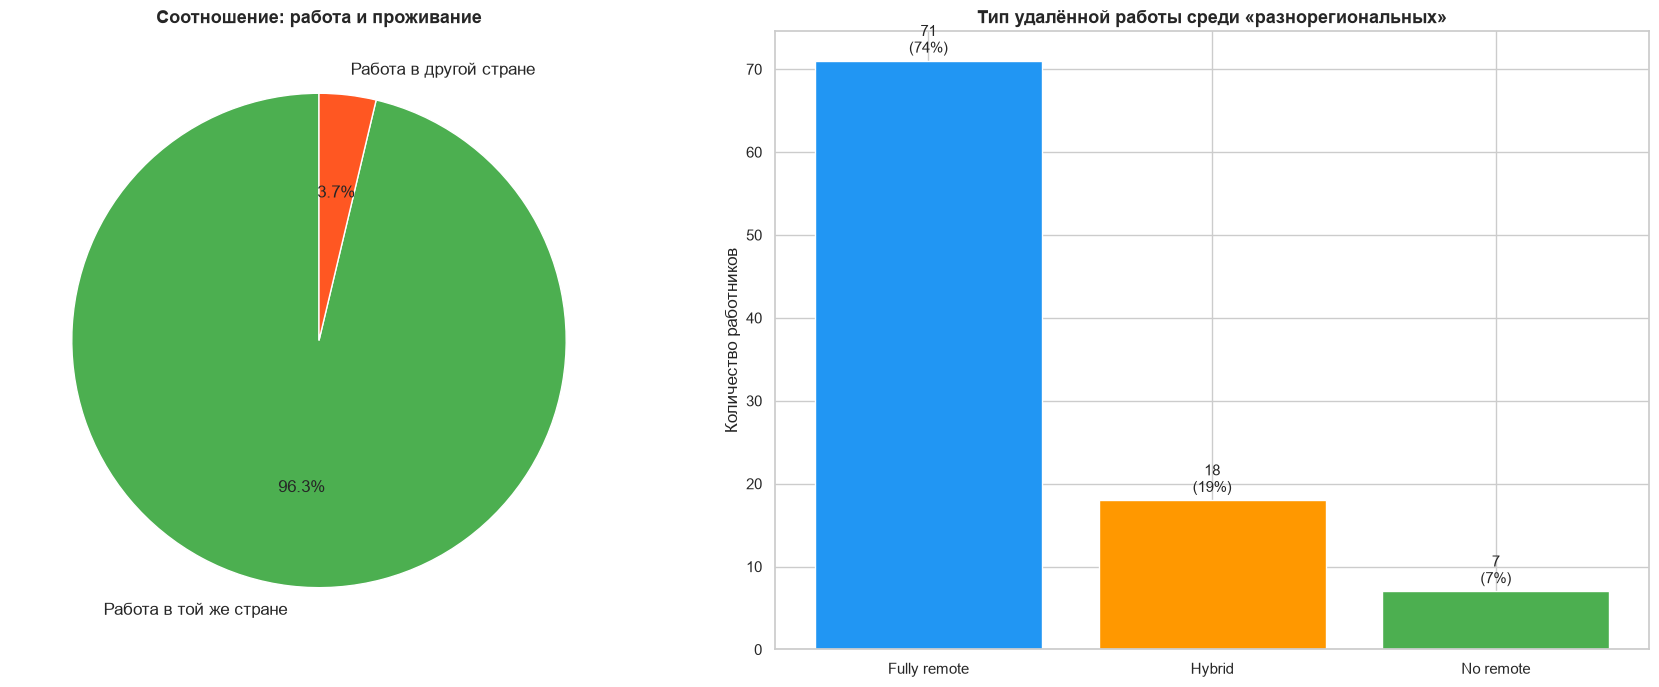

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

labels = ['Работа в той же стране', 'Работа в другой стране']
sizes = [len(same_region), len(diff_region)]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Соотношение: работа и проживание', fontsize=13, fontweight='bold')

# Bar chart: удалёнка среди разнорегиональных
remote_counts = diff_region['remote_type'].value_counts()
axes[1].bar(remote_counts.index, remote_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
axes[1].set_title('Тип удалённой работы среди «разнорегиональных»', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Количество работников')
for i, (idx, val) in enumerate(remote_counts.items()):
    axes[1].text(i, val + 1, f'{val}\n({val/len(diff_region)*100:.0f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot_5h_cross_border.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по 5h:**
- Только **96 человек (3.7%)** работают на компанию из другой страны.
- Из них **71 человек (74%)** работают полностью удалённо — это логично.
- Больше всего «разнорегиональных» работников проживают в **Индии (15)**, Франции (6) и Испании (5).
- Подавляющее большинство (96.3%) работают в стране, где находится компания.

### 5i. Дополнительные инсайты

In [32]:
# Инсайт 1: Уровень опыта — главный драйвер зарплаты
exp_map = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
df['exp_label'] = df['experience_level'].map(exp_map)

exp_stats = df.groupby('exp_label')['salary_in_usd'].median().reindex(['Entry-level', 'Mid-level', 'Senior', 'Executive'])
print('Медианная зарплата по уровню опыта:')
print(exp_stats)
print(f'\nРост от Entry до Executive: {exp_stats.iloc[-1] / exp_stats.iloc[0]:.1f}x')
print(f'Корреляция опыта и зарплаты: {df["experience_level"].map({"EN":0, "MI":1, "SE":2, "EX":3}).corr(df["salary_in_usd"]):.4f}')

Медианная зарплата по уровню опыта:
exp_label
Entry-level     61900.0
Mid-level       95000.0
Senior         148800.0
Executive      189618.5
Name: salary_in_usd, dtype: float64

Рост от Entry до Executive: 3.1x
Корреляция опыта и зарплаты: 0.4705


In [33]:
# Инсайт 2: Доля удалёнки по годам
remote_by_year = df.groupby('work_year').apply(lambda x: (x['remote_ratio'] == 100).sum() / len(x) * 100)
print('Доля полностью удалённой работы по годам:')
print(remote_by_year.round(1))

Доля полностью удалённой работы по годам:
work_year
2020    50.7
2021    52.2
2022    55.7
2023    36.9
dtype: float64


In [34]:
# Инсайт 3: Корреляционная матрица
df['exp_num'] = df['experience_level'].map({'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3})
df['size_num'] = df['company_size'].map({'S': 0, 'M': 1, 'L': 2})

corr_cols = ['work_year', 'salary_in_usd', 'remote_ratio', 'exp_num', 'size_num']
corr_matrix = df[corr_cols].corr()
print('Корреляционная матрица:')
print(corr_matrix.round(3))

Корреляционная матрица:
               work_year  salary_in_usd  remote_ratio  exp_num  size_num
work_year          1.000          0.237        -0.219    0.209    -0.140
salary_in_usd      0.237          1.000        -0.085    0.471    -0.002
remote_ratio      -0.219         -0.085         1.000   -0.055     0.037
exp_num            0.209          0.471        -0.055    1.000    -0.068
size_num          -0.140         -0.002         0.037   -0.068     1.000


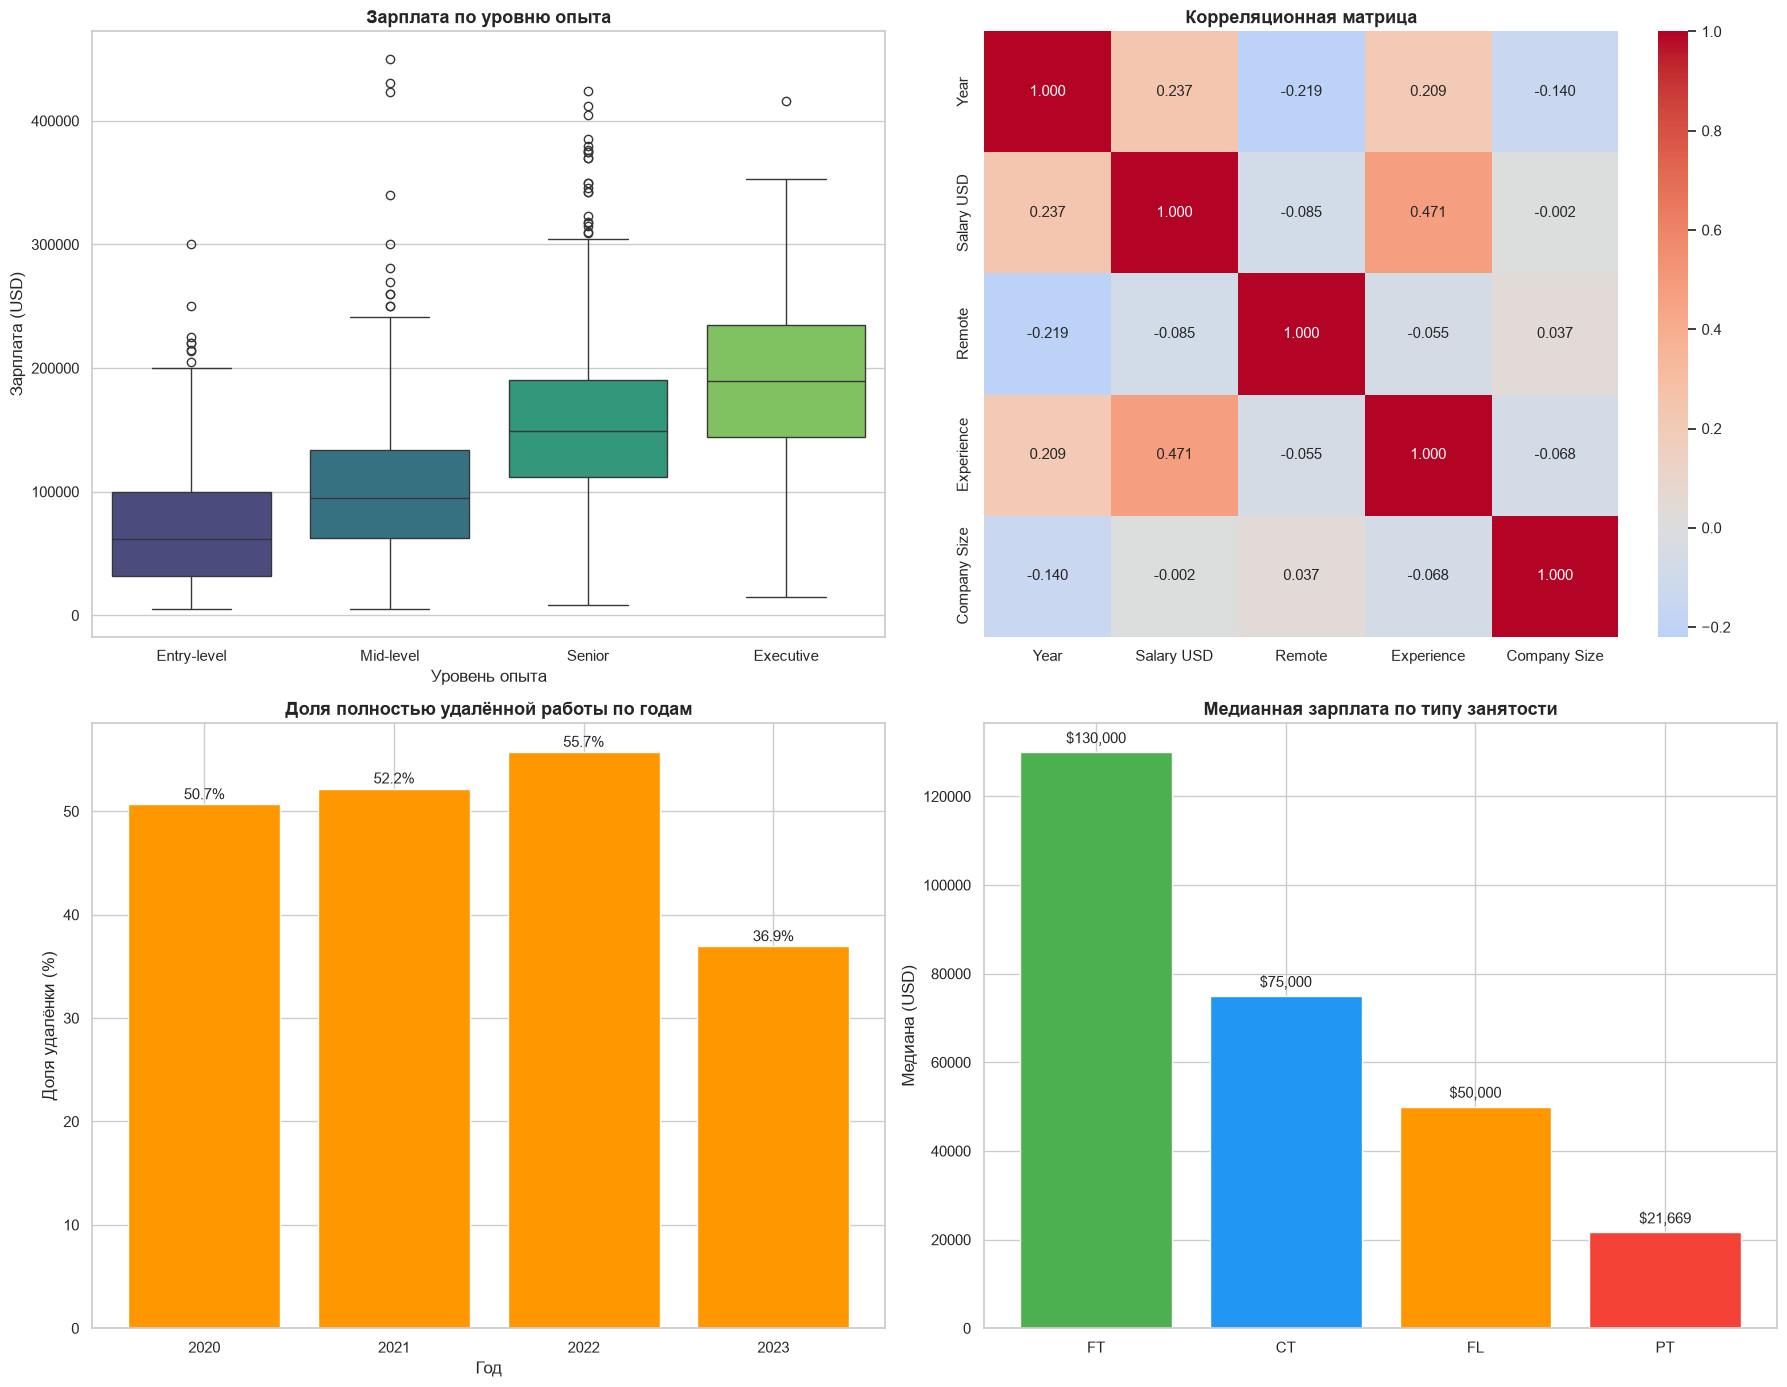

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 📊 1. Зарплата по уровню опыта (Seaborn boxplot)
order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
# ИСПРАВЛЕНИЕ: добавили hue='exp_label' и отключили легенду legend=False
sns.boxplot(data=df, x='exp_label', y='salary_in_usd', order=order, 
            hue='exp_label', hue_order=order, ax=axes[0,0], palette='viridis', legend=False)
axes[0,0].set_title('Зарплата по уровню опыта', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Уровень опыта')
axes[0,0].set_ylabel('Зарплата (USD)')

# 📊 2. Доля удалёнки по годам (Matplotlib bar)
axes[1,0].bar(remote_by_year.index, remote_by_year.values, color='#FF9800', edgecolor='white')
axes[1,0].set_title('Доля полностью удалённой работы по годам', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Год')
axes[1,0].set_ylabel('Доля удалёнки (%)')
axes[1,0].set_xticks(remote_by_year.index)
for x, y in zip(remote_by_year.index, remote_by_year.values):
    axes[1,0].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=11)

# 📊 3. Корреляционная тепловая карта (Seaborn heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,1], fmt='.3f',
            xticklabels=['Year', 'Salary USD', 'Remote', 'Experience', 'Company Size'],
            yticklabels=['Year', 'Salary USD', 'Remote', 'Experience', 'Company Size'])
axes[0,1].set_title('Корреляционная матрица', fontsize=13, fontweight='bold')

# 📊 4. Зарплата по типу занятости (Matplotlib bar)
emp_stats = df.groupby('employment_type')['salary_in_usd'].median().sort_values(ascending=False)
axes[1,1].bar(emp_stats.index, emp_stats.values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'], edgecolor='white')
axes[1,1].set_title('Медианная зарплата по типу занятости', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Медиана (USD)')
for i, (idx, val) in enumerate(emp_stats.items()):
    axes[1,1].text(i, val + 2000, f'${val:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot_5i_insights.png', dpi=150, bbox_inches='tight')
plt.show()


**Дополнительные инсайты:**

1. **Опыт — главный фактор зарплаты** (r = 0.471). Рост от Entry-level ($61 900) до Executive ($189 619) — в 3 раза.
2. **Удалёнка падает после пандемии**: пик в 2022 (55.7%), спад в 2023 (36.9%) — компании возвращают людей в офисы.
3. **Full-time (FT)** — самый оплачиваемый тип занятости (медиана $135 000). Contract и Part-time — значительно ниже.
4. **Год работы слабо коррелирует с зарплатой** (r = 0.21) — важен опыт, а не просто время.
5. **Размер компании почти не влияет** (r = 0.01) — важнее местоположение и уровень специалиста.

---
## 📋 Итоговые выводы по всем пунктам кейса

| # | Вопрос | Ответ |
|---|---|---|
| **a** | Самые высокооплачиваемые должности | Data Science Tech Lead ($375K), Cloud Data Architect ($250K), Data Lead ($212K). Выбросы: 29 записей (> $310K), чаще у Data Scientist и ML Engineer |
| **b** | Влияние удалённой работы | Корреляция r = −0.08 — **не влияет**. No remote $137.5K, Fully remote $130K, Hybrid $63K |
| **c** | Зависимость от размера компании | Средние компании платят больше ($137K), корреляция **отсутствует** (r = 0.01) |
| **d** | Популярные страны | США — лидер (1929 вакансий, $146K). Индия — самая низкая ($18K). Разрыв в 8 раз |
| **e** | Медиана по должностям | От $5.1K (Power BI Developer) до $375K (Data Science Tech Lead) |
| **f** | Рост 2020 → 2023 | Общий рост **88.9%** ($74K → $140K). Data Analyst +210%, Data Scientist +139%, Research Scientist −39% |
| **g** | Портрет топ-1% | Senior Data Engineer, США, Medium-компания, офис, $310K–$450K |
| **h** | Разные регионы | 3.7% (96 чел.) работают в другой стране, 74% из них — полностью удалённо |
| **i** | Доп. инсайты | Опыт — главный драйвер (r = 0.47). Удалёнка падает после пандемии. FT — самый оплачиваемый тип занятости |